✅ Step 0 (공통 준비) — 라이브러리/기본 설정

In [2]:
# 현재 커널 환경에 pandas와 필수 라이브러리 설치
!pip install pandas matplotlib tqdm


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [3]:
# ============================================================
# [STEP 0 - CELL 1] Imports & Global Config
# ============================================================

import os
import re
import zipfile
from pathlib import Path
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# 재현성
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", device)

# 최대 길이 (토큰 기준) - 필요하면 조정
MAX_LEN = 40

# Special tokens (이전 노트북의 SPM id 관례(0~3)와 맞추기 위해 이렇게 둡니다)
PAD_TOKEN = "<pad>"
BOS_TOKEN = "<start>"
EOS_TOKEN = "<end>"
UNK_TOKEN = "<unk>"

PAD_ID = 0
BOS_ID = 1
EOS_ID = 2
UNK_ID = 3

DEVICE: cuda


✅ Step 1. 데이터 다운로드 

In [4]:
# ============================================================
# [STEP 1] Load ChatbotData.csv -> questions, answers
# ============================================================

csv_path = Path("/workspace/data/Chatbot_data/ChatbotData.csv")
assert csv_path.exists(), f"CSV 파일을 찾지 못했습니다: {csv_path}"

df = pd.read_csv(csv_path)
print(df.head())
print(df.columns)

# 일반적으로 Q/A 컬럼이 존재합니다.
# (예외 대비) 컬럼명이 다르면 아래 후보에서 찾습니다.
q_col_candidates = ["Q", "question", "questions", "Question"]
a_col_candidates = ["A", "answer", "answers", "Answer"]

q_col = next((c for c in q_col_candidates if c in df.columns), None)
a_col = next((c for c in a_col_candidates if c in df.columns), None)

assert q_col is not None, f"질문 컬럼을 찾지 못했습니다. columns={df.columns.tolist()}"
assert a_col is not None, f"답변 컬럼을 찾지 못했습니다. columns={df.columns.tolist()}"

questions = df[q_col].astype(str).tolist()
answers   = df[a_col].astype(str).tolist()

print("questions:", len(questions), "| answers:", len(answers))
print("Q sample:", questions[0])
print("A sample:", answers[0])

                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0
Index(['Q', 'A', 'label'], dtype='str')
questions: 11823 | answers: 11823
Q sample: 12시 땡!
A sample: 하루가 또 가네요.


In [5]:
questions?

Type:        list
String form: ['12시 땡!', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다', '3박4일 정도 놀러가고 싶다', 'PPL 심하네', 'SD카드 망가졌어', 'SD카드 안돼', ' <...>  싶어', '훔쳐보는 것도 눈치 보임.', '훔쳐보는 것도 눈치 보임.', '흑기사 해주는 짝남.', '힘든 연애 좋은 연애라는게 무슨 차이일까?', '힘들어서 결혼할까봐']
Length:      11823
Docstring:  
Built-in mutable sequence.

If no argument is given, the constructor creates a new empty list.
The argument must be an iterable if specified.

In [6]:
answers?

Type:        list
String form: ['하루가 또 가네요.', '위로해 드립니다.', '여행은 언제나 좋죠.', '여행은 언제나 좋죠.', '눈살이 찌푸려지죠.', '다시 새로 사는 게 마음 편해요.', '다시 <...> 티가 나니까 눈치가 보이는 거죠!', '훔쳐보는 거 티나나봐요.', '설렜겠어요.', '잘 헤어질 수 있는 사이 여부인 거 같아요.', '도피성 결혼은 하지 않길 바라요.']
Length:      11823
Docstring:  
Built-in mutable sequence.

If no argument is given, the constructor creates a new empty list.
The argument must be an iterable if specified.

✅ Step 2. 데이터 정제

In [7]:
# ============================================================
# [STEP 2 - CELL 1] preprocess_sentence
# ============================================================

def preprocess_sentence(sentence: str) -> str:
    """
    - 영문자는 소문자로 변환
    - 영문/한글/숫자/주요 특수문자만 허용, 나머지는 제거
    - 토크나이저가 문장부호 처리 가능하므로 문장부호 양옆 공백 추가 등은 생략
    """
    s = str(sentence).lower().strip()

    # 허용: 한글, 영문, 숫자, 공백, 그리고 주요 특수문자(대화 데이터에 흔한 것)
    # . , ? ! ~ % @ # & ( ) [ ] { } : ; ' " - _ + = / \ |
    s = re.sub(r"[^0-9a-zA-Z가-힣\s\.\,\?\!\~\%\@\#\&\(\)\[\]\{\}\:\;\'\"\-\_\+\=\/\\\|]", "", s)

    # 공백 정리
    s = re.sub(r"\s+", " ", s).strip()
    return s

print(preprocess_sentence("카톡!!"))

카톡!!


In [8]:
preprocess_sentence?

Signature: preprocess_sentence(sentence: str) -> str
Docstring:
- 영문자는 소문자로 변환
- 영문/한글/숫자/주요 특수문자만 허용, 나머지는 제거
- 토크나이저가 문장부호 처리 가능하므로 문장부호 양옆 공백 추가 등은 생략
File:      /tmp/ipykernel_2086/3760182333.py
Type:      function

✅ Step 3. 데이터 토큰화

In [9]:
# 1. KoNLPy 및 필수 데이터 분석 도구 설치
!pip install konlpy pandas matplotlib tqdm

# 2. Mecab 실구동을 위한 필수 패키지 설치 (mecab-python3와 사전)
!pip install mecab-python3 unidic-lite


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [10]:
# ============================================================
# [STEP 3 - CELL 1] Mecab 초기화 (사전 경로 지정 버전)
# ============================================================

from konlpy.tag import Mecab
import unidic_lite

# unidic-lite가 설치된 실제 경로를 가져와서 Mecab에 넣어줍니다.
dic_path = unidic_lite.DICDIR
mecab = Mecab(dic_path)
morphs = mecab.morphs

print("✅ Mecab이 성공적으로 로드되었습니다!")
print("테스트:", morphs("아싸! 이제 잘 돌아간다."))

✅ Mecab이 성공적으로 로드되었습니다!
테스트: ['아싸', '!', '이제', '잘', '돌아간다', '.']


In [11]:
morphs?

Signature: morphs(phrase)
Docstring: Parse phrase to morphemes.
File:      /usr/local/lib/python3.11/dist-packages/konlpy/tag/_mecab.py
Type:      method

✅ Step 3-1. 코퍼스 정제 

In [12]:
# ============================================================
# [STEP 3 - CELL 2] make_corpus() 이름 유지
# ============================================================

def make_corpus(src_sentences, tgt_sentences, tokenizer_func, max_len=40):
    """
    반환: (src_corpus, tgt_corpus)
    - src/tgt 각각 preprocess_sentence 후 tokenizer_func 적용
    - 토큰 길이 >= max_len 인 문장 제외 (요구사항: 일정 길이 이상 제외)
    - 중복 문장 제외 (src는 src대로, tgt는 tgt대로)
    - 쌍이 흐트러지지 않도록 keep mask를 적용
    """
    assert len(src_sentences) == len(tgt_sentences)

    src_corpus = []
    tgt_corpus = []

    seen_src = set()
    seen_tgt = set()

    for s, t in zip(src_sentences, tgt_sentences):
        s_clean = preprocess_sentence(s)
        t_clean = preprocess_sentence(t)

        s_tokens = tokenizer_func(s_clean)
        t_tokens = tokenizer_func(t_clean)

        # 길이 제한 (>= max_len 제외)
        if len(s_tokens) >= max_len or len(t_tokens) >= max_len:
            continue

        # 중복 제거 (각각 따로)
        s_key = " ".join(s_tokens)
        t_key = " ".join(t_tokens)

        if s_key in seen_src:
            continue
        if t_key in seen_tgt:
            continue

        seen_src.add(s_key)
        seen_tgt.add(t_key)

        src_corpus.append(s_tokens)
        tgt_corpus.append(t_tokens)

    return src_corpus, tgt_corpus

In [13]:
# ============================================================
# [STEP 3 - CELL 3] build_corpus() (프로젝트 요구 이름 추가 제공)
# - 내부적으로 make_corpus를 호출하여 "기존 이름 유지" + "과제 요구 충족"
# ============================================================

def build_corpus(src_sentences, tgt_sentences, tokenize_func, max_len=40):
    return make_corpus(src_sentences, tgt_sentences, tokenize_func, max_len=max_len)

que_corpus, ans_corpus = build_corpus(questions, answers, morphs, max_len=MAX_LEN)

print("que_corpus:", len(que_corpus), "ans_corpus:", len(ans_corpus))
print("Q tokens sample:", que_corpus[0])
print("A tokens sample:", ans_corpus[0])

que_corpus: 7737 ans_corpus: 7737
Q tokens sample: ['12', '시', '땡', '!']
A tokens sample: ['하루가', '또', '가네요', '.']


✅ Step 4. Augmentation — Word2Vec + lexical_sub

In [14]:
# Word2Vec 학습을 위한 gensim 설치
!pip install gensim


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [15]:
# 1. 기존 NumPy 삭제 후 호환성이 검증된 버전으로 설치
!pip uninstall -y numpy
!pip install "numpy<2.0.0"

# 2. Gensim 재설치 (최신 버전 유지)
!pip install --upgrade gensim

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [16]:
# ============================================================
# [STEP 4 - SINGLE CELL] Train local Word2Vec + Safe Sample Check
# ============================================================
# pip install gensim  (안 되어 있으면 설치)

from gensim.models import Word2Vec

# Step3에서 생성된 토큰 코퍼스 사용
sentences = que_corpus + ans_corpus

# 로컬 Word2Vec 학습 (과제용 빠른 세팅)
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=200,
    window=5,
    min_count=1,   # ✅ 1로 설정 (vocab 누락 방지)
    workers=4,
    sg=1,          # skip-gram
    epochs=20,
    seed=SEED
)

wv = w2v_model.wv
print("Local WV ready. vocab:", len(wv.key_to_index))

# --- 안전한 sample similar 출력 ---
if sentences and len(sentences[0]) > 0:
    tok0 = sentences[0][0]
    if tok0 in wv.key_to_index:
        print("sample similar:", tok0, "=>", wv.most_similar(tok0, topn=5))
    else:
        any_tok = next(iter(wv.key_to_index.keys()))
        print("sample similar:", any_tok, "=>", wv.most_similar(any_tok, topn=5))
else:
    print("No valid tokens for sample check.")

Local WV ready. vocab: 18010
sample similar: 12 => [('시', 0.9913109540939331), ('입니다', 0.9900757670402527), ('개월이네', 0.989321231842041), ('두달이', 0.9890723824501038), ('다되가네', 0.9888072609901428)]


In [17]:
# ============================================================
# [STEP 4 - CELL 2] lexical_sub() (이전 노트북 이름 유지)
# ============================================================

def lexical_sub(tokens, wv_model, replace_prob=0.3, topn=10):
    """
    tokens: List[str]
    - 각 토큰에 대해 replace_prob 확률로 유사어로 치환
    - special token은 아직 넣지 않았으므로 일반 토큰만 처리
    """
    if len(tokens) == 0:
        return tokens

    new_tokens = tokens[:]
    for i, tok in enumerate(tokens):
        if random.random() > replace_prob:
            continue
        if tok not in wv_model.key_to_index:
            continue

        # 유사어 후보
        sims = wv_model.most_similar(tok, topn=topn)
        cand = [w for (w, score) in sims if w != tok]
        if len(cand) == 0:
            continue

        new_tokens[i] = random.choice(cand)

    return new_tokens

# quick test
print(que_corpus[0])
print(lexical_sub(que_corpus[0], wv, replace_prob=0.5))

['12', '시', '땡', '!']
['12', '새벽', '대박', '!']


In [18]:
# ============================================================
# [STEP 4 - CELL 3] Build augmented dataset (≈ 3x)
# 1) (aug_que, ori_ans)
# 2) (ori_que, aug_ans)
# 3) (ori_que, ori_ans)
# ============================================================

aug_que_corpus = [lexical_sub(toks, wv, replace_prob=0.3) for toks in que_corpus]
aug_ans_corpus = [lexical_sub(toks, wv, replace_prob=0.3) for toks in ans_corpus]

# 3배 구성
que_corpus_3x = que_corpus + aug_que_corpus + que_corpus
ans_corpus_3x = ans_corpus + ans_corpus + aug_ans_corpus

assert len(que_corpus_3x) == len(ans_corpus_3x)
print("3x size:", len(que_corpus_3x))

3x size: 23211


✅ Step 5. 데이터 벡터화

In [19]:
# ============================================================
# [STEP 5 - CELL 1] Add <start>/<end> to target corpus
# ============================================================

ans_corpus_3x_se = [[BOS_TOKEN] + toks + [EOS_TOKEN] for toks in ans_corpus_3x]
que_corpus_3x_se = [toks[:] for toks in que_corpus_3x]  # 질문은 보통 start/end 안 붙여도 OK

print(ans_corpus_3x_se[0][:10], "...", ans_corpus_3x_se[0][-5:])

['<start>', '하루가', '또', '가네요', '.', '<end>'] ... ['하루가', '또', '가네요', '.', '<end>']


In [20]:
# ============================================================
# [STEP 5 - CELL 2] Build shared vocab & vectorize
# ============================================================

def build_vocab(corpus_list, min_freq=2):
    """
    corpus_list: List[List[str]] 토큰 리스트들의 리스트
    반환:
      token2id, id2token
    """
    from collections import Counter
    cnt = Counter()
    for toks in corpus_list:
        cnt.update(toks)

    token2id = {
        PAD_TOKEN: PAD_ID,
        BOS_TOKEN: BOS_ID,
        EOS_TOKEN: EOS_ID,
        UNK_TOKEN: UNK_ID,
    }
    id2token = {v:k for k,v in token2id.items()}

    # 빈도 기준으로 추가
    for tok, f in cnt.most_common():
        if tok in token2id:
            continue
        if f < min_freq:
            continue
        token2id[tok] = len(token2id)
        id2token[token2id[tok]] = tok

    return token2id, id2token

# vocab은 질문+답변 전체에서 구축 (공유)
token2id, id2token = build_vocab(que_corpus_3x_se + ans_corpus_3x_se, min_freq=2)
VOCAB_SIZE = len(token2id)
print("VOCAB_SIZE:", VOCAB_SIZE)

def encode(tokens):
    return [token2id.get(t, UNK_ID) for t in tokens]

def pad_to_maxlen(ids, max_len, pad_id=PAD_ID):
    if len(ids) > max_len:
        return ids[:max_len]
    return ids + [pad_id] * (max_len - len(ids))

# 벡터화
enc_train = np.array([pad_to_maxlen(encode(toks), MAX_LEN) for toks in que_corpus_3x_se], dtype=np.int64)
dec_train = np.array([pad_to_maxlen(encode(toks), MAX_LEN) for toks in ans_corpus_3x_se], dtype=np.int64)

print("enc_train:", enc_train.shape, "dec_train:", dec_train.shape)

VOCAB_SIZE: 18014
enc_train: (23211, 40) dec_train: (23211, 40)


In [21]:
# ============================================================
# [STEP 5 - DIAG CELL] UNK/PAD/EOS 비율을 "정수 ID 배열" 기준으로 다시 측정
# - 위치: STEP 5에서 enc_train/dec_train 만든 직후 (STEP 6 전에)
# ============================================================

import numpy as np

def ratio_id(arr, _id):
    arr = np.asarray(arr)
    return float((arr == _id).sum() / max(arr.size, 1))

def eos_pos_stats(arr, eos_id=EOS_ID, pad_id=PAD_ID):
    arr = np.asarray(arr)
    eos_pos = []
    no_eos = 0
    for row in arr:
        idx = np.where(row == eos_id)[0]
        if len(idx) == 0:
            no_eos += 1
        else:
            eos_pos.append(int(idx[0]))
    eos_pos = np.array(eos_pos) if len(eos_pos) > 0 else np.array([])
    return {
        "no_eos_rows": int(no_eos),
        "eos_pos_mean": float(eos_pos.mean()) if eos_pos.size else None,
        "eos_pos_min": int(eos_pos.min()) if eos_pos.size else None,
        "eos_pos_max": int(eos_pos.max()) if eos_pos.size else None,
    }

print("=== enc_train ratios ===")
print("PAD:", ratio_id(enc_train, PAD_ID))
print("UNK:", ratio_id(enc_train, UNK_ID))
print("EOS:", ratio_id(enc_train, EOS_ID), " (참고)")

print("\n=== dec_train ratios ===")
print("PAD:", ratio_id(dec_train, PAD_ID))
print("UNK:", ratio_id(dec_train, UNK_ID))
print("EOS:", ratio_id(dec_train, EOS_ID))
print("BOS:", ratio_id(dec_train, BOS_ID))

print("\n=== dec_train EOS position stats ===")
print(eos_pos_stats(dec_train, EOS_ID, PAD_ID))

=== enc_train ratios ===
PAD: 0.8947460255913144
UNK: 0.0
EOS: 0.0  (참고)

=== dec_train ratios ===
PAD: 0.8281342897763991
UNK: 0.0
EOS: 0.025
BOS: 0.025

=== dec_train EOS position stats ===
{'no_eos_rows': 0, 'eos_pos_mean': 5.8746284089440355, 'eos_pos_min': 2, 'eos_pos_max': 25}


In [22]:
# ============================================================
# [STEP 5.5 - TUNE CELL] MAX_LEN 재설정 + enc/dec 재생성 (+ 안전 점검)
# - 위치: STEP 5 - DIAG CELL 다음, STEP 6 Minimal pack 이전
# - 앞단(토큰화/사전/함수/클래스)은 그대로 유지
# - 목적: PAD 비율 폭탄(현재 enc PAD~0.86)을 줄여 학습/attention 안정화
# ============================================================

import numpy as np

# -----------------------------
# 0) 길이 분포 확인 (현재 que_corpus/ans_corpus는 "토큰 리스트"임)
# -----------------------------
q_lens = np.array([len(x) for x in que_corpus], dtype=np.int32)
a_lens = np.array([len(x) for x in ans_corpus], dtype=np.int32)

print("Q len: mean", q_lens.mean(), "p90", np.percentile(q_lens,90), "p95", np.percentile(q_lens,95), "p99", np.percentile(q_lens,99), "max", q_lens.max())
print("A len: mean", a_lens.mean(), "p90", np.percentile(a_lens,90), "p95", np.percentile(a_lens,95), "p99", np.percentile(a_lens,99), "max", a_lens.max())

# -----------------------------
# 1) MAX_LEN 자동 추천 (p95 기반 + 약간 여유)
#    - 질문/답변 중 더 긴 쪽 기준
#    - 너무 길게 잡으면 PAD 폭탄이 다시 생김
# -----------------------------
p95_len = int(max(np.percentile(q_lens,95), np.percentile(a_lens,95)))
recommended_max_len = min(max(p95_len + 8, 20), 32)   # 16~32 범위로 clamp (너무 커지지 않게) 추천p95_len = 12 이므로 + 8 -> 20임
print("\n[RECOMMEND] MAX_LEN =", recommended_max_len, "(p95 기반)")

# -----------------------------
# 2) 실제로 MAX_LEN을 바꿀지 결정 (자동으로 바꾸는 기본값)
#    - 원하시면 아래 USE_RECOMMENDED=False로 하고 직접 MAX_LEN 지정해도 됨
# -----------------------------
USE_RECOMMENDED = True
if USE_RECOMMENDED:
    MAX_LEN = recommended_max_len

print("[APPLIED] MAX_LEN =", MAX_LEN)

# -----------------------------
# 3) pad_to_maxlen 재정의 (Step5 로직 유지하면서 길이만 반영)
# -----------------------------
def pad_to_maxlen(ids, max_len, pad_id=PAD_ID):
    ids = list(ids)
    if len(ids) > max_len:
        return ids[:max_len]
    return ids + [pad_id] * (max_len - len(ids))

# -----------------------------
# 4) enc/dec 다시 생성
#    - encode() / token2id / PAD_ID / BOS_ID / EOS_ID 는 Step5 것 그대로 사용
#    - enc: 질문 토큰 -> ids -> pad
#    - dec: [BOS] + 답변 토큰 ids + [EOS] -> pad
# -----------------------------
enc_all = []
dec_all = []

for q_tokens, a_tokens in zip(que_corpus, ans_corpus):
    enc_ids = pad_to_maxlen(encode(q_tokens), MAX_LEN, PAD_ID)

    # 답변: BOS + tokens + EOS (EOS 보존형)
    a_ids = encode(a_tokens)
    
    # ✅ 길면 끝부분을 잘라서라도 EOS를 반드시 넣기
    max_body = MAX_LEN - 2            # BOS, EOS 자리 확보
    a_ids = a_ids[:max_body]          # 본문만 자름
    
    dec_ids = [BOS_ID] + a_ids + [EOS_ID]
    dec_ids = pad_to_maxlen(dec_ids, MAX_LEN, PAD_ID)


    enc_all.append(enc_ids)
    dec_all.append(dec_ids)

enc_all = np.array(enc_all, dtype=np.int32)
dec_all = np.array(dec_all, dtype=np.int32)

# 기존 변수명 유지(노트북이 enc_train/dec_train을 참조하므로 그대로 덮어쓰기)
enc_train = enc_all
dec_train = dec_all

print("\n[REBUILD DONE] enc_train:", enc_train.shape, "dec_train:", dec_train.shape)

# -----------------------------
# 5) 다시 DIAG (PAD 비율이 실제로 내려갔는지 확인)
# -----------------------------
def ratio_id(arr, _id):
    arr = np.asarray(arr)
    return float((arr == _id).sum() / max(arr.size, 1))

def eos_pos_stats(arr, eos_id=EOS_ID):
    arr = np.asarray(arr)
    eos_pos = []
    no_eos = 0
    for row in arr:
        idx = np.where(row == eos_id)[0]
        if len(idx) == 0:
            no_eos += 1
        else:
            eos_pos.append(int(idx[0]))
    eos_pos = np.array(eos_pos) if len(eos_pos) > 0 else np.array([])
    return {
        "no_eos_rows": int(no_eos),
        "eos_pos_mean": float(eos_pos.mean()) if eos_pos.size else None,
        "eos_pos_min": int(eos_pos.min()) if eos_pos.size else None,
        "eos_pos_max": int(eos_pos.max()) if eos_pos.size else None,
    }

print("\n=== (AFTER REBUILD) enc_train ratios ===")
print("PAD:", ratio_id(enc_train, PAD_ID))
print("UNK:", ratio_id(enc_train, UNK_ID))

print("\n=== (AFTER REBUILD) dec_train ratios ===")
print("PAD:", ratio_id(dec_train, PAD_ID))
print("UNK:", ratio_id(dec_train, UNK_ID))
print("EOS:", ratio_id(dec_train, EOS_ID))
print("BOS:", ratio_id(dec_train, BOS_ID))

print("\n=== (AFTER REBUILD) dec_train EOS position stats ===")
print(eos_pos_stats(dec_train, EOS_ID))

# -----------------------------
# 6) (선택) shared_fc/shared_emb 안전 점검
#    - src/tgt vocab이 같은지(같은 token2id를 쓰는지) 확인 목적
# -----------------------------
try:
    print("\n[CHECK] vocab_size:", vocab_size)
except Exception:
    pass

Q len: mean 4.210158976347421 p90 7.0 p95 8.0 p99 10.0 max 16
A len: mean 4.8746284089440355 p90 7.0 p95 8.0 p99 11.0 max 24

[RECOMMEND] MAX_LEN = 20 (p95 기반)
[APPLIED] MAX_LEN = 20

[REBUILD DONE] enc_train: (7737, 20) dec_train: (7737, 20)

=== (AFTER REBUILD) enc_train ratios ===
PAD: 0.7894920511826289
UNK: 0.0

=== (AFTER REBUILD) dec_train ratios ===
PAD: 0.6563396665374176
UNK: 0.0
EOS: 0.05
BOS: 0.05

=== (AFTER REBUILD) dec_train EOS position stats ===
{'no_eos_rows': 0, 'eos_pos_mean': 5.873206669251648, 'eos_pos_min': 2, 'eos_pos_max': 19}


✅ Step 6. 훈련하기

In [23]:
# ============================================================
# [STEP 6 - HPARAM RE-CHECK] 하이퍼파라미터 재설정
# ============================================================

# 만약 앞에서 설정값이 날아갔다면 여기서 다시 잡아줍니다.
LR = 1e-4
DROPOUT = 0.2
CLIP_NORM = 1.0
LABEL_SMOOTHING = 0.1

# VOCAB_SIZE와 MAX_LEN은 이전 셀에서 이미 확인되었겠지만, 혹시 모르니 체크
print(f"[RE-CHECK] DROPOUT: {DROPOUT}, VOCAB_SIZE: {VOCAB_SIZE}, DEVICE: {device}")

[RE-CHECK] DROPOUT: 0.2, VOCAB_SIZE: 18014, DEVICE: cuda


In [24]:
# ============================================================
# [STEP 6 - CELL 1] Transformer Model Architecture
# ============================================================

import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class TransformerChatbot(nn.Module):
    def __init__(self, vocab_size, d_model=256, nhead=8, num_layers=4, dim_feedforward=512, dropout=0.2):
        super().__init__()
        self.d_model = d_model
        
        # 1. Embedding & Positional Encoding
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len=MAX_LEN, dropout=dropout)
        
        # 2. Transformer
        # batch_first=True 설정으로 (batch, seq, feature) 형태를 다룹니다.
        self.transformer = nn.Transformer(
            d_model=d_model, 
            nhead=nhead, 
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        
        # 3. Final Output Layer
        self.fc_out = nn.Linear(d_model, vocab_size)

    def generate_mask(self, sz):
        mask = torch.triu(torch.ones(sz, sz) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask.to(device)

    def forward(self, src, tgt):
        # 마스크 생성 (디코더가 미래의 단어를 보지 못하게 함)
        tgt_mask = self.generate_mask(tgt.size(1))
        
        src_emb = self.pos_encoding(self.embedding(src) * math.sqrt(self.d_model))
        tgt_emb = self.pos_encoding(self.embedding(tgt) * math.sqrt(self.d_model))
        
        output = self.transformer(src_emb, tgt_emb, tgt_mask=tgt_mask)
        return self.fc_out(output)

# 모델 생성 및 GPU 전송
model = TransformerChatbot(VOCAB_SIZE, dropout=DROPOUT).to(device)

print(f"✅ 모델 생성 완료 및 {device}로 이동됨")
print(f"✅ 모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

✅ 모델 생성 완료 및 cuda로 이동됨
✅ 모델 파라미터 수: 14,513,758


In [25]:
# 모델을 다시 한번 device(cuda)로 확실히 보냅니다.
model.to(device)

print(f"현재 모델 위치: {next(model.parameters()).device}")
print(f"활성화된 디바이스: {device}")

현재 모델 위치: cuda:0
활성화된 디바이스: cuda


In [26]:
# ============================================================
# [STEP 6 - CELL 1] Minimal Transformer pack (defines Transformer)
# - 기존 클래스/함수명 유지
# - 변경: loss_function(label_smoothing 적용), train_step(CLIP_NORM 반영)
# ============================================================

def positional_encoding(position, d_model):
    def get_angles(pos, i):
        angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
        return pos * angle_rates

    angle_rads = get_angles(
        np.arange(position)[:, np.newaxis],
        np.arange(d_model)[np.newaxis, :]
    )
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    pe = angle_rads[np.newaxis, ...]
    return torch.tensor(pe, dtype=torch.float32)

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.depth = d_model // n_heads

        self.wq = nn.Linear(d_model, d_model)
        self.wk = nn.Linear(d_model, d_model)
        self.wv = nn.Linear(d_model, d_model)

        self.fc = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)

    def split_heads(self, x):
        B, T, C = x.size()
        x = x.view(B, T, self.n_heads, self.depth).transpose(1, 2)  # (B,h,T,depth)
        return x

    def forward(self, q, k, v, mask=None, return_attn=False):
        q = self.split_heads(self.wq(q))
        k = self.split_heads(self.wk(k))
        v = self.split_heads(self.wv(v))

        dk = q.size(-1)
        scores = torch.matmul(q, k.transpose(-2, -1)) / torch.sqrt(
            torch.tensor(dk, device=q.device, dtype=torch.float32)
        )

        # mask: keep=1, mask=0 가정
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn = torch.softmax(scores, dim=-1)   # (B,h,Tq,Tk)
        attn = self.drop(attn)

        out = torch.matmul(attn, v)            # (B,h,Tq,depth)
        out = out.transpose(1, 2).contiguous() # (B,Tq,h,depth)
        B, T, _, _ = out.size()
        out = out.view(B, T, self.n_heads * self.depth)
        out = self.fc(out)

        if return_attn:
            return out, attn
        return out

class FFN(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )
    def forward(self, x):
        return self.net(x)

class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = FFN(d_model, d_ff, dropout)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.ln1(x + self.drop(self.mha(x, x, x, mask)))
        x = self.ln2(x + self.drop(self.ffn(x)))
        return x

class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.mha1 = MultiHeadAttention(d_model, n_heads, dropout)  # self-attn
        self.mha2 = MultiHeadAttention(d_model, n_heads, dropout)  # enc-dec
        self.ffn = FFN(d_model, d_ff, dropout)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.ln3 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

        self.last_cross_attn = None  # ✅ 유지

    def forward(self, x, enc, look_mask=None, pad_mask=None):
        x = self.ln1(x + self.drop(self.mha1(x, x, x, look_mask)))

        out, attn = self.mha2(x, enc, enc, pad_mask, return_attn=True)
        self.last_cross_attn = attn  # (B,h,Tt,Ts)
        x = self.ln2(x + self.drop(out))

        x = self.ln3(x + self.drop(self.ffn(x)))
        return x

class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, vocab_size, pos_len, dropout=0.1, shared_emb=None):
        super().__init__()
        self.d_model = d_model
        self.emb = shared_emb if shared_emb is not None else nn.Embedding(vocab_size, d_model)
        self.pe = positional_encoding(pos_len, d_model)
        self.drop = nn.Dropout(dropout)
        self.layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])

    def forward(self, x, mask=None):
        B, T = x.size()
        x = self.emb(x) * torch.sqrt(torch.tensor(self.d_model, device=x.device, dtype=torch.float32))
        x = x + self.pe[:, :T, :].to(x.device)
        x = self.drop(x)
        for layer in self.layers:
            x = layer(x, mask)
        return x

class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, vocab_size, pos_len, dropout=0.1, shared_emb=None):
        super().__init__()
        self.d_model = d_model
        self.emb = shared_emb if shared_emb is not None else nn.Embedding(vocab_size, d_model)
        self.pe = positional_encoding(pos_len, d_model)
        self.drop = nn.Dropout(dropout)
        self.layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])

    def forward(self, x, enc, look_mask=None, pad_mask=None):
        B, T = x.size()
        x = self.emb(x) * torch.sqrt(torch.tensor(self.d_model, device=x.device, dtype=torch.float32))
        x = x + self.pe[:, :T, :].to(x.device)
        x = self.drop(x)
        for layer in self.layers:
            x = layer(x, enc, look_mask, pad_mask)
        return x

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.1, shared_fc=True, shared_emb=True):
        super().__init__()
        self.shared_emb = nn.Embedding(src_vocab_size, d_model) if shared_emb else None
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, src_vocab_size, pos_len, dropout, shared_emb=self.shared_emb)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, tgt_vocab_size, pos_len, dropout,
                              shared_emb=self.shared_emb if shared_emb else None)

        self.fc = nn.Linear(d_model, tgt_vocab_size)
        if shared_fc and shared_emb:
            self.fc.weight = self.shared_emb.weight

        self.last_cross_attn = None  # ✅ 유지

    def forward(self, src, tgt_inp, enc_mask, dec_enc_mask, dec_mask):
        enc = self.encoder(src, enc_mask)
        dec = self.decoder(tgt_inp, enc, dec_mask, dec_enc_mask)

        if len(self.decoder.layers) > 0:
            self.last_cross_attn = self.decoder.layers[-1].last_cross_attn

        logits = self.fc(dec)
        return logits

def generate_padding_mask(seq):
    # keep=1, pad=0
    return (seq != PAD_ID).unsqueeze(1).unsqueeze(2).int()  # (B,1,1,T)

def generate_lookahead_mask(T):
    return torch.tril(torch.ones((T, T), dtype=torch.int32))  # (T,T)

def generate_masks(src, tgt_inp):
    enc_mask = generate_padding_mask(src)     # (B,1,1,Ts)
    dec_enc_mask = generate_padding_mask(src) # (B,1,1,Ts)

    T = tgt_inp.size(1)
    look = generate_lookahead_mask(T).to(tgt_inp.device)  # (T,T)
    look = look.unsqueeze(0).unsqueeze(0)                 # (1,1,T,T)

    dec_pad = (tgt_inp != PAD_ID).unsqueeze(1).unsqueeze(2).int() # (B,1,1,T)
    dec_mask = look * dec_pad                                     # (B,1,T,T)
    return enc_mask, dec_enc_mask, dec_mask

# ✅ PATCH: label smoothing 반영 (함수명 유지)
def loss_function(logits, tgt_out):
    B, T, V = logits.size()
    try:
        loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=float(LABEL_SMOOTHING))
    except TypeError:
        loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_ID)
    return loss_fn(logits.reshape(B*T, V), tgt_out.reshape(B*T))

# ✅ PATCH: CLIP_NORM 반영 (함수명 유지)
def train_step(src, tgt, model, optimizer):
    model.train()
    tgt_inp = tgt[:, :-1]
    tgt_out = tgt[:, 1:]

    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_inp)
    enc_mask = enc_mask.to(src.device)
    dec_enc_mask = dec_enc_mask.to(src.device)
    dec_mask = dec_mask.to(src.device)

    optimizer.zero_grad()
    logits = model(src, tgt_inp, enc_mask, dec_enc_mask, dec_mask)
    loss = loss_function(logits, tgt_out)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), float(CLIP_NORM))
    optimizer.step()
    return loss

In [27]:
# ============================================================
# [STEP 6 - CELL 2] Dataset / Dataloader
# ============================================================

from torch.utils.data import Dataset, DataLoader

class ChatDataset(Dataset):
    def __init__(self, enc, dec):
        self.enc = torch.tensor(enc, dtype=torch.long)
        self.dec = torch.tensor(dec, dtype=torch.long)

    def __len__(self):
        return len(self.enc)

    def __getitem__(self, idx):
        return self.enc[idx], self.dec[idx]

BATCH_SIZE = 64
train_ds = ChatDataset(enc_train, dec_train)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

print("Batches:", len(train_loader))
print("enc_train:", enc_train.shape, "dec_train:", dec_train.shape)

Batches: 121
enc_train: (7737, 20) dec_train: (7737, 20)


In [28]:
# ============================================================
# [STEP 6 - CELL 3] Build model + Optimizer
# ============================================================

n_layers = 1
d_model  = 368     # 유지 (원하면 384로 바꿔도 OK)
n_heads  = 8
d_ff     = 1024
dropout  = float(DROPOUT)
pos_len  = MAX_LEN

model = Transformer(
    n_layers=n_layers,
    d_model=d_model,
    n_heads=n_heads,
    d_ff=d_ff,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=pos_len,
    dropout=dropout,
    shared_fc=True,
    shared_emb=True,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=float(LR))

print("Model ready:", model.__class__.__name__)

Model ready: Transformer


Epoch 01 | loss=77.3258
Epoch 02 | loss=34.6992
Epoch 03 | loss=31.0964
Epoch 04 | loss=28.4699
Epoch 05 | loss=26.4840
Epoch 06 | loss=24.8763
Epoch 07 | loss=23.4716
Epoch 08 | loss=22.2444
Epoch 09 | loss=21.2024
Epoch 10 | loss=20.1716
Epoch 11 | loss=19.3508
Epoch 12 | loss=18.4478
Epoch 13 | loss=17.6823
Epoch 14 | loss=16.8962
Epoch 15 | loss=16.2647
Epoch 16 | loss=15.6145
Epoch 17 | loss=15.0264
Epoch 18 | loss=14.4466
Epoch 19 | loss=13.9513
Epoch 20 | loss=13.5061
Epoch 21 | loss=13.0562
Epoch 22 | loss=12.6121
Epoch 23 | loss=12.2398
Epoch 24 | loss=11.8219
Epoch 25 | loss=11.5312
Epoch 26 | loss=11.2272
Epoch 27 | loss=10.8788
Epoch 28 | loss=10.6303
Epoch 29 | loss=10.3439
Epoch 30 | loss=10.1124
Epoch 31 | loss=9.9166
Epoch 32 | loss=9.6881
Epoch 33 | loss=9.5116
Epoch 34 | loss=9.3303
Epoch 35 | loss=9.1744
Epoch 36 | loss=9.0028
Epoch 37 | loss=8.8307
Epoch 38 | loss=8.6627
Epoch 39 | loss=8.5340
Epoch 40 | loss=8.3753
Epoch 41 | loss=8.2642
Epoch 42 | loss=8.1168
Epoc

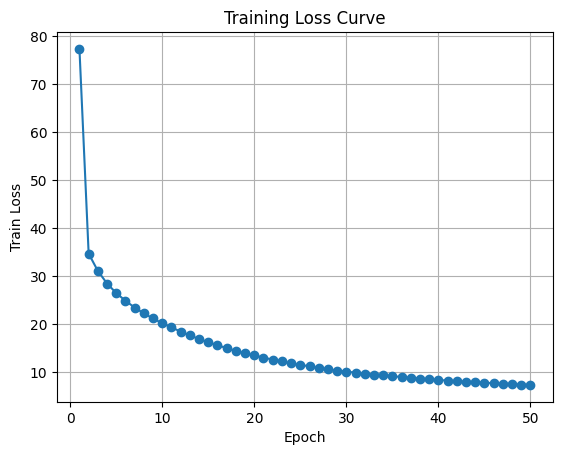

In [29]:
# ============================================================
# [STEP 6 - CELL 4] Train loop + Loss curve
# ============================================================

import matplotlib.pyplot as plt

train_losses = []

EPOCHS = 50

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0

    for src, tgt in train_loader:
        src = src.to(device)
        tgt = tgt.to(device)

        loss = train_step(src, tgt, model, optimizer)
        total_loss += float(loss.item())

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch:02d} | loss={avg_loss:.4f}")

plt.figure()
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

Epoch 01 | loss=7.2499
Epoch 02 | loss=7.1981
Epoch 03 | loss=7.0897
Epoch 04 | loss=7.0175
Epoch 05 | loss=6.9500
Epoch 06 | loss=6.8699
Epoch 07 | loss=6.8036
Epoch 08 | loss=6.7448
Epoch 09 | loss=6.6878
Epoch 10 | loss=6.6264
Epoch 11 | loss=6.5723
Epoch 12 | loss=6.4925
Epoch 13 | loss=6.4540
Epoch 14 | loss=6.3969
Epoch 15 | loss=6.3425
Epoch 16 | loss=6.2997
Epoch 17 | loss=6.2617
Epoch 18 | loss=6.2072
Epoch 19 | loss=6.1621
Epoch 20 | loss=6.1212
Epoch 21 | loss=6.0876
Epoch 22 | loss=6.0403
Epoch 23 | loss=5.9980
Epoch 24 | loss=5.9744
Epoch 25 | loss=5.9341
Epoch 26 | loss=5.9137
Epoch 27 | loss=5.8786
Epoch 28 | loss=5.8480
Epoch 29 | loss=5.8201
Epoch 30 | loss=5.8046
Epoch 31 | loss=5.7725
Epoch 32 | loss=5.7410
Epoch 33 | loss=5.7367
Epoch 34 | loss=5.7019
Epoch 35 | loss=5.6800
Epoch 36 | loss=5.6591
Epoch 37 | loss=5.6371
Epoch 38 | loss=5.6240
Epoch 39 | loss=5.5951
Epoch 40 | loss=5.5765
Epoch 41 | loss=5.5629
Epoch 42 | loss=5.5241
Epoch 43 | loss=5.5232
Epoch 44 | 

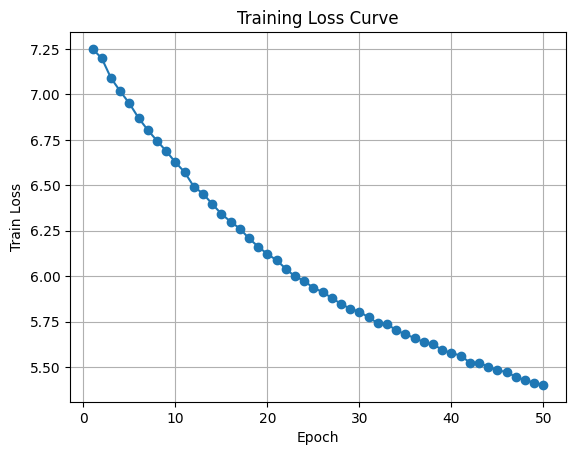

In [30]:
# ============================================================
# [STEP 6 - CELL 4] Train loop + Loss curve
# ============================================================

import matplotlib.pyplot as plt

train_losses = []

EPOCHS = 50

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0

    for src, tgt in train_loader:
        src = src.to(device)
        tgt = tgt.to(device)

        loss = train_step(src, tgt, model, optimizer)
        total_loss += float(loss.item())

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch:02d} | loss={avg_loss:.4f}")

plt.figure()
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

🚀 연장 훈련 시작: 추가 100 에폭 진행합니다.
Extended Epoch 001 | loss=5.3835
Extended Epoch 002 | loss=5.3762
Extended Epoch 003 | loss=5.3468
Extended Epoch 004 | loss=5.3393
Extended Epoch 005 | loss=5.3247
Extended Epoch 006 | loss=5.3001
Extended Epoch 007 | loss=5.2852
Extended Epoch 008 | loss=5.2755
Extended Epoch 009 | loss=5.2483
Extended Epoch 010 | loss=5.2415
Extended Epoch 011 | loss=5.2282
Extended Epoch 012 | loss=5.2220
Extended Epoch 013 | loss=5.2048
Extended Epoch 014 | loss=5.1953
Extended Epoch 015 | loss=5.1714
Extended Epoch 016 | loss=5.1563
Extended Epoch 017 | loss=5.1355
Extended Epoch 018 | loss=5.1364
Extended Epoch 019 | loss=5.1211
Extended Epoch 020 | loss=5.1104
Extended Epoch 021 | loss=5.0953
Extended Epoch 022 | loss=5.0791
Extended Epoch 023 | loss=5.0622
Extended Epoch 024 | loss=5.0587
Extended Epoch 025 | loss=5.0376
Extended Epoch 026 | loss=5.0334
Extended Epoch 027 | loss=5.0158
Extended Epoch 028 | loss=5.0153
Extended Epoch 029 | loss=4.9890
Extended Epoch

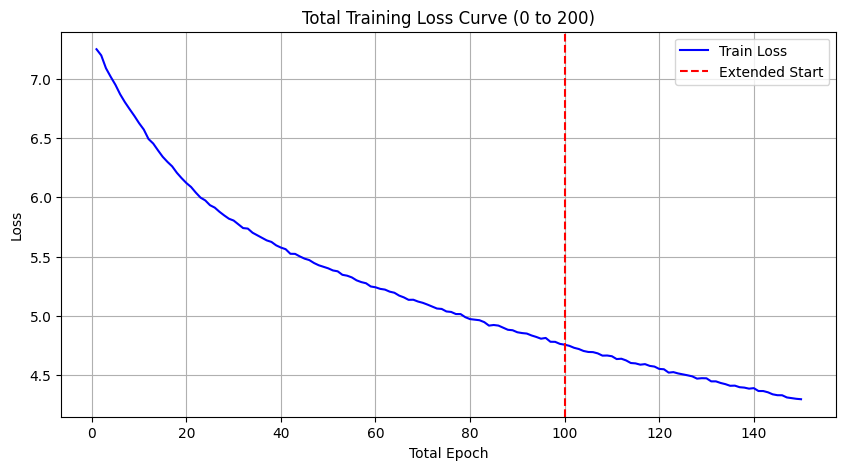

✅ 200 에폭 모델 저장 완료: chatbot_model_200.pt


In [40]:
# ============================================================
# [STEP 6 - CELL 4.5] 연장 훈련 (추가 100 Epoch)
# ============================================================

# 추가로 학습할 에폭 수 설정 (이미 100번 했으므로 100번 더 해서 총 200번 달성)
EXTENDED_EPOCHS = 100 

print(f"🚀 연장 훈련 시작: 추가 {EXTENDED_EPOCHS} 에폭 진행합니다.")

for epoch in range(1, EXTENDED_EPOCHS + 1):
    model.train()
    total_loss = 0.0

    for src, tgt in train_loader:
        src = src.to(device)
        tgt = tgt.to(device)

        # 기존에 정의된 train_step 함수를 그대로 사용합니다.
        loss = train_step(src, tgt, model, optimizer)
        total_loss += float(loss.item())

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss) # 기존 loss 리스트에 누적
    
    # 10회마다 혹은 매번 진행 상황 출력
    print(f"Extended Epoch {epoch:03d} | loss={avg_loss:.4f}")

# 전체 학습 결과 시각화 (0~200 에폭 전체)
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses)+1), train_losses, color='blue', label='Train Loss')
plt.axvline(x=100, color='red', linestyle='--', label='Extended Start') # 연장 시작 지점 표시
plt.xlabel("Total Epoch")
plt.ylabel("Loss")
plt.title("Total Training Loss Curve (0 to 200)")
plt.legend()
plt.grid(True)
plt.show()

# ✅ 모델 중간 저장 (중요: 학습한 결과가 날아가지 않게 파일로 저장합니다)
torch.save(model.state_dict(), "chatbot_model_200.pt")
print("✅ 200 에폭 모델 저장 완료: chatbot_model_200.pt")

In [49]:
# [STEP 6 - CELL 4.6] 모델 최종 저장
import torch

# 모델의 가중치(weights)를 파일로 저장합니다.
save_path = "chatbot_model_200.pt"
torch.save(model.state_dict(), save_path)

print(f"✅ 모델 저장 완료! 파일명: {save_path}")

✅ 모델 저장 완료! 파일명: chatbot_model_200.pt


In [41]:
# ============================================================
# [STEP 6 - CELL 5] translate() - 반복 붕괴 방지 디코딩 (함수명 유지)
# ============================================================

import torch
import torch.nn.functional as F

def _apply_repetition_penalty(logits, generated_ids, penalty=1.25):
    if penalty is None or penalty <= 1.0:
        return logits
    for tid in set(generated_ids):
        logits[tid] /= penalty
    return logits

def _ban_repeat_ngram(logits, generated_ids, n=4):
    if n is None or n <= 1 or len(generated_ids) < (n - 1):
        return logits
    prefix = tuple(generated_ids[-(n-1):])
    banned = set()
    for i in range(len(generated_ids) - (n - 1)):
        if tuple(generated_ids[i:i+(n-1)]) == prefix:
            banned.add(generated_ids[i+(n-1)])
    if banned:
        logits[list(banned)] = -1e9
    return logits

@torch.no_grad()
def translate(tokens, model, max_len=MAX_LEN,
              temperature=0.7,
              top_k=20,
              repetition_penalty=1.25,
              no_repeat_ngram_size=4,
              min_len=3):
    model.eval()

    src_ids = pad_to_maxlen(encode(tokens), MAX_LEN)
    src = torch.tensor([src_ids], dtype=torch.long, device=device)

    ys = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)

    for _ in range(max_len - 1):
        enc_mask, dec_enc_mask, dec_mask = generate_masks(src, ys)

        logits = model(src, ys,
                       enc_mask.to(device),
                       dec_enc_mask.to(device),
                       dec_mask.to(device))  # (1,T,V)

        next_logits = logits[0, -1, :].clone()

        if ys.size(1) < min_len:
            next_logits[EOS_ID] = -1e9

        gen_ids = ys[0].tolist()
        next_logits = _apply_repetition_penalty(next_logits, gen_ids, penalty=repetition_penalty)
        next_logits = _ban_repeat_ngram(next_logits, gen_ids, n=no_repeat_ngram_size)

        next_logits = next_logits / max(temperature, 1e-6)

        if top_k is not None and top_k > 0:
            topv, topi = torch.topk(next_logits, k=min(top_k, next_logits.size(-1)))
            probs = F.softmax(topv, dim=-1)
            next_id = topi[torch.multinomial(probs, 1)].item()
        else:
            probs = F.softmax(next_logits, dim=-1)
            next_id = torch.multinomial(probs, 1).item()

        ys = torch.cat([ys, torch.tensor([[next_id]], dtype=torch.long, device=device)], dim=1)

        if next_id == EOS_ID:
            break

    pred_ids = ys.squeeze(0).tolist()[1:]  # drop BOS
    pred_tokens = [id2token.get(i, UNK_TOKEN) for i in pred_ids]
    return pred_tokens

In [42]:
# ============================================================
# [STEP 6 - CELL 6] Run given examples
# ============================================================

examples = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야.",
]

for s in examples:
    s_clean = preprocess_sentence(s)
    s_tokens = morphs(s_clean)
    out_tokens = translate(s_tokens, model)
    print("\nQ:", s)
    print("A:", " ".join(out_tokens))


Q: 지루하다, 놀러가고 싶어.
A: 더 있을 거예요 . <end>

Q: 오늘 일찍 일어났더니 피곤하다.
A: 저랑 그게 . <end>

Q: 간만에 여자친구랑 데이트 하기로 했어.
A: 없애는 . <end>

Q: 집에 있는다는 소리야.
A: 될 거예요 . <end>


In [43]:
# ============================================================
# [STEP 6 - CELL 7] (선택) 간단 sanity check
# - <start>/<end>가 dec_train에 잘 들어갔는지 확인
# ============================================================

print("BOS_ID:", BOS_ID, "EOS_ID:", EOS_ID, "PAD_ID:", PAD_ID)
print("dec_train[0][:20] =", dec_train[0][:20])
print("EOS in dec_train[0] ? ", (EOS_ID in dec_train[0]))

BOS_ID: 1 EOS_ID: 2 PAD_ID: 0
dec_train[0][:20] = [   1 2354   41 3041    4    2    0    0    0    0    0    0    0    0
    0    0    0    0    0    0]
EOS in dec_train[0] ?  True


✅ Step 7. 성능 측정

In [44]:
# ============================================================
# [STEP 7 - CELL 1] Metrics: calculate_bleu() + calculate_rouge()
# - calculate_bleu 이름 유지 (token list 기준)
# - ROUGE-1/2/L: P/R/F1 모두 출력 가능
# ============================================================

import numpy as np

def calculate_bleu(references, hypotheses, max_n=4, smooth=1e-9):
    """
    references: List[List[str]]  (정답 토큰 시퀀스들)
    hypotheses: List[List[str]]  (예측 토큰 시퀀스들)
    간단한 corpus BLEU (n-gram precision 평균 * brevity penalty)
    """
    def ngram_counts(tokens, n):
        from collections import Counter
        return Counter([tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)])

    precisions = []
    for n in range(1, max_n+1):
        match = 0
        total = 0
        for ref, hyp in zip(references, hypotheses):
            ref_cnt = ngram_counts(ref, n)
            hyp_cnt = ngram_counts(hyp, n)
            total += sum(hyp_cnt.values())
            for g, c in hyp_cnt.items():
                match += min(c, ref_cnt.get(g, 0))
        precisions.append((match + smooth) / (total + smooth))

    ref_len = sum(len(r) for r in references)
    hyp_len = sum(len(h) for h in hypotheses)
    if hyp_len == 0:
        return 0.0
    bp = 1.0 if hyp_len > ref_len else np.exp(1 - ref_len / hyp_len)

    bleu = bp * np.exp(np.mean(np.log(precisions)))
    return float(bleu)

def _ngram_counts(tokens, n):
    from collections import Counter
    return Counter([tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)])

def _rouge_n(ref, hyp, n=1):
    ref_ngrams = _ngram_counts(ref, n)
    hyp_ngrams = _ngram_counts(hyp, n)
    overlap = sum((ref_ngrams & hyp_ngrams).values())

    ref_total = sum(ref_ngrams.values())
    hyp_total = sum(hyp_ngrams.values())

    recall = overlap / ref_total if ref_total > 0 else 0.0
    precision = overlap / hyp_total if hyp_total > 0 else 0.0
    f1 = (2*precision*recall/(precision+recall)) if (precision+recall) > 0 else 0.0
    return precision, recall, f1

def _lcs_length(a, b):
    m, n = len(a), len(b)
    dp = [[0]*(n+1) for _ in range(m+1)]
    for i in range(m):
        ai = a[i]
        for j in range(n):
            if ai == b[j]:
                dp[i+1][j+1] = dp[i][j] + 1
            else:
                dp[i+1][j+1] = max(dp[i][j+1], dp[i+1][j])
    return dp[m][n]

def _rouge_l(ref, hyp):
    lcs = _lcs_length(ref, hyp)
    recall = lcs / len(ref) if len(ref) > 0 else 0.0
    precision = lcs / len(hyp) if len(hyp) > 0 else 0.0
    f1 = (2*precision*recall/(precision+recall)) if (precision+recall) > 0 else 0.0
    return precision, recall, f1

def calculate_rouge(references, hypotheses):
    """
    references: List[List[str]]
    hypotheses: List[List[str]]
    return: dict with avg rouge-1/2/l (P/R/F1)
    """
    r1_p=r1_r=r1_f=0.0
    r2_p=r2_r=r2_f=0.0
    rl_p=rl_r=rl_f=0.0
    N = max(len(hypotheses), 1)

    for ref, hyp in zip(references, hypotheses):
        p,r,f = _rouge_n(ref, hyp, n=1); r1_p+=p; r1_r+=r; r1_f+=f
        p,r,f = _rouge_n(ref, hyp, n=2); r2_p+=p; r2_r+=r; r2_f+=f
        p,r,f = _rouge_l(ref, hyp);      rl_p+=p; rl_r+=r; rl_f+=f

    return {
        "rouge1": {"P": r1_p/N, "R": r1_r/N, "F1": r1_f/N},
        "rouge2": {"P": r2_p/N, "R": r2_r/N, "F1": r2_f/N},
        "rougeL": {"P": rl_p/N, "R": rl_r/N, "F1": rl_f/N},
    }

In [35]:
# ============================================================
# [STEP 7 - CELL 2] Evaluate (BLEU + ROUGE)  ✅ 한 번만 실행
# - translate()는 Step6에서 정의된 것을 사용
# ============================================================

# 평가 샘플 수 (너무 느리면 줄이세요)
N_EVAL = 2000
eval_ques = que_corpus[:N_EVAL]
eval_ans  = ans_corpus[:N_EVAL]

def strip_special(toks):
    # 문자열 토큰 기준으로 특수토큰 제거
    specials = set()
    for x in [BOS_TOKEN, EOS_TOKEN, PAD_TOKEN, UNK_TOKEN]:
        if isinstance(x, str):
            specials.add(x)
    return [t for t in toks if t not in specials]

references, hypotheses = [], []

for q_tokens, a_tokens in zip(eval_ques, eval_ans):
    pred_tokens = translate(q_tokens, model)

    # 정답/예측 토큰 모두 특수토큰 제거 후 비교
    references.append(strip_special(a_tokens))
    hypotheses.append(strip_special(pred_tokens))

bleu = calculate_bleu(references, hypotheses)
rouge = calculate_rouge(references, hypotheses)

print(f"BLEU (N={len(hypotheses)}): {bleu:.4f}")
print("ROUGE-1  P/R/F1:", rouge["rouge1"])
print("ROUGE-2  P/R/F1:", rouge["rouge2"])
print("ROUGE-L  P/R/F1:", rouge["rougeL"])

BLEU (N=2000): 0.0893
ROUGE-1  P/R/F1: {'P': 0.6067503246753253, 'R': 0.4301947594072607, 'F1': 0.47902102669861774}
ROUGE-2  P/R/F1: {'P': 0.19837303391053382, 'R': 0.11289004884004888, 'F1': 0.13262426462426477}
ROUGE-L  P/R/F1: {'P': 0.591583261183262, 'R': 0.4173281232656246, 'F1': 0.46562365113816223}


/tmp/ipykernel_2086/1471032006.py:103: UserWarning: Glyph 45440 (\N{HANGUL SYLLABLE NOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2086/1471032006.py:103: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2086/1471032006.py:103: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2086/1471032006.py:103: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2086/1471032006.py:103: UserWarning: Glyph 49910 (\N{HANGUL SYLLABLE SIP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2086/1471032006.py:103: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2086/1471032006.py:103: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tigh

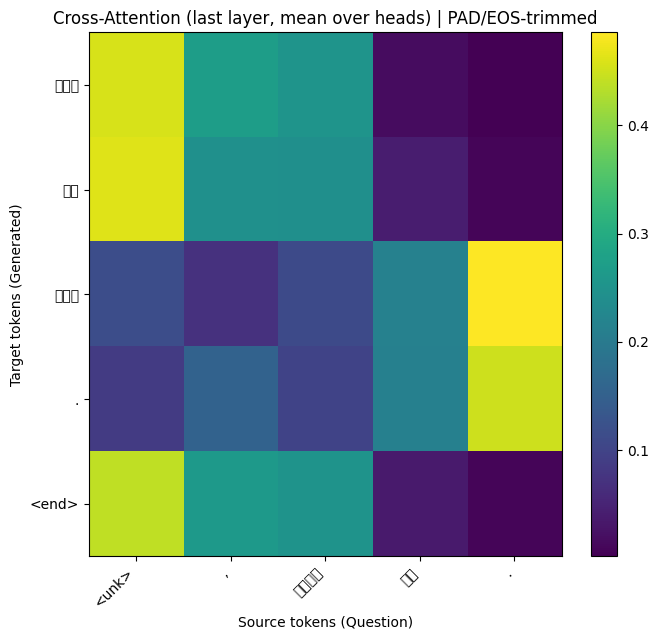

In [45]:
# ============================================================
# [STEP 7 - CELL 3] Attention Map (Cross-Attention)  ✅ FIXED
# - 함수명 plot_cross_attention 유지
# - PAD/EOS 길이 정확 슬라이싱
# - (선택) 한글 폰트까지 포함
# ============================================================

import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def _setup_korean_font():
    candidates = [
        "C:/Windows/Fonts/NanumGothic.ttf",
        "C:/Windows/Fonts/nanumgothic.ttf",
        "C:/Windows/Fonts/malgun.ttf",
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
    ]
    for p in candidates:
        if os.path.exists(p):
            fp = fm.FontProperties(fname=p)
            plt.rcParams["font.family"] = fp.get_name()
            plt.rcParams["axes.unicode_minus"] = False
            return
    plt.rcParams["axes.unicode_minus"] = False

_setup_korean_font()

def _len_until_pad_id(ids, pad_id=PAD_ID):
    ids = list(ids)
    try:
        return ids.index(pad_id)
    except ValueError:
        return len(ids)

def _len_until_eos_id(ids, eos_id=EOS_ID):
    ids = list(ids)
    try:
        return ids.index(eos_id) + 1  # EOS 포함
    except ValueError:
        return len(ids)

def plot_cross_attention(question_text, drop_bos=True):
    model.eval()
    q_clean = preprocess_sentence(question_text)
    q_tokens = morphs(q_clean)

    # src ids (MAX_LEN로 패딩된 상태)
    src_ids = pad_to_maxlen(encode(q_tokens), MAX_LEN)
    src = torch.tensor([src_ids], dtype=torch.long, device=device)

    # ✅ Step6의 translate 정책과 "같은 방식"으로 생성해야 맵이 일치함
    #    (Step6 translate가 sampling이므로, 여기서도 translate를 호출)
    pred_tokens = translate(q_tokens, model)  # List[str]
    pred_ids = [token2id.get(t, UNK_ID) for t in pred_tokens]  # token2id가 Step5에 있어야 함

    # translate는 BOS를 이미 drop했으니, ys는 BOS + pred_ids 형태로 복원
    ys_ids = [BOS_ID] + pred_ids
    # 혹시 EOS가 없으면 뒤에 붙여서 안정화
    if (len(ys_ids) < MAX_LEN) and (EOS_ID not in ys_ids):
        ys_ids.append(EOS_ID)
    ys_ids = ys_ids[:MAX_LEN]
    ys = torch.tensor([ys_ids], dtype=torch.long, device=device)

    # attn 캡처를 위해 1회 forward 실행
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, ys)
    with torch.no_grad():
        _ = model(src, ys, enc_mask.to(device), dec_enc_mask.to(device), dec_mask.to(device))

    attn = getattr(model, "last_cross_attn", None)
    if attn is None:
        print("No attention captured. (model.last_cross_attn is None)")
        print("→ Step6 pack의 DecoderLayer/Transformer에 last_cross_attn 저장이 있는지 확인")
        return

    attn = attn[0].detach().cpu().numpy()   # (h,Tt,Ts)
    attn_mean = attn.mean(axis=0)           # (Tt,Ts)

    src_len = _len_until_pad_id(src_ids, PAD_ID)
    tgt_len = _len_until_eos_id(ys_ids, EOS_ID)

    src_show = [id2token.get(int(i), UNK_TOKEN) for i in src_ids[:src_len]]
    tgt_show = [id2token.get(int(i), UNK_TOKEN) for i in ys_ids[:tgt_len]]

    attn_show = attn_mean[:tgt_len, :src_len]

    # ✅ BOS 제거 옵션
    if drop_bos and len(tgt_show) > 0 and ys_ids[0] == BOS_ID:
        tgt_show = tgt_show[1:]
        attn_show = attn_show[1:, :]

    plt.figure(figsize=(min(12, 0.6*len(src_show)+4), min(10, 0.5*len(tgt_show)+4)))
    plt.imshow(attn_show, aspect="auto")
    plt.xticks(range(len(src_show)), src_show, rotation=45, ha="right")
    plt.yticks(range(len(tgt_show)), tgt_show)
    plt.xlabel("Source tokens (Question)")
    plt.ylabel("Target tokens (Generated)")
    plt.title("Cross-Attention (last layer, mean over heads) | PAD/EOS-trimmed")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

# 예시
plot_cross_attention("지루하다, 놀러가고 싶어.")

/tmp/ipykernel_2086/1471032006.py:103: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2086/1471032006.py:103: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2086/1471032006.py:103: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2086/1471032006.py:103: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2086/1471032006.py:103: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2086/1471032006.py:103: UserWarning: Glyph 52828 (\N{HANGUL SYLLABLE CIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2086/1471032006.py:103: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tigh

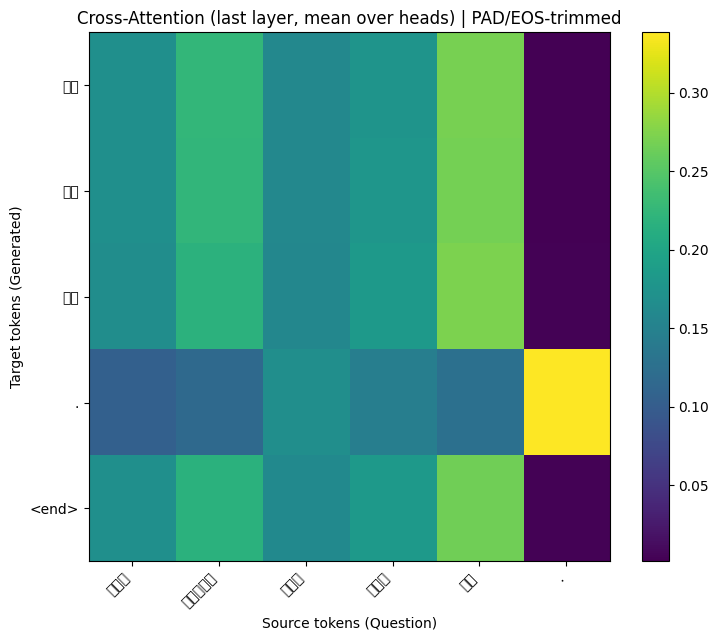

In [46]:
plot_cross_attention("간만에 여자친구랑 데이트 하기로 했어.")

/tmp/ipykernel_2086/1471032006.py:103: UserWarning: Glyph 51665 (\N{HANGUL SYLLABLE JIB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2086/1471032006.py:103: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2086/1471032006.py:103: UserWarning: Glyph 46112 (\N{HANGUL SYLLABLE DOEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2086/1471032006.py:103: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2086/1471032006.py:103: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2086/1471032006.py:103: UserWarning: Glyph 51080 (\N{HANGUL SYLLABLE ISS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2086/1471032006.py:103: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tigh

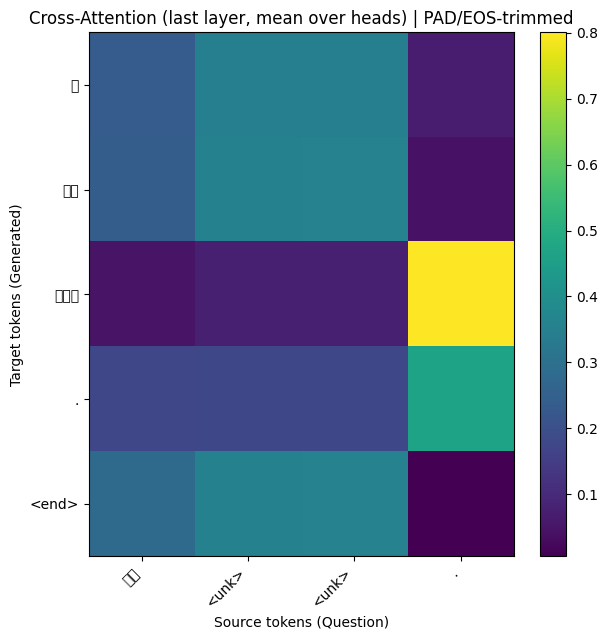

In [47]:
plot_cross_attention("집에 있는다는 소리야.")

/tmp/ipykernel_2086/1471032006.py:103: UserWarning: Glyph 51665 (\N{HANGUL SYLLABLE JIB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2086/1471032006.py:103: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2086/1471032006.py:103: UserWarning: Glyph 46112 (\N{HANGUL SYLLABLE DOEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2086/1471032006.py:103: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2086/1471032006.py:103: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2086/1471032006.py:103: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46112 (\N{HANGUL SYLLABLE DOEL}) missing f

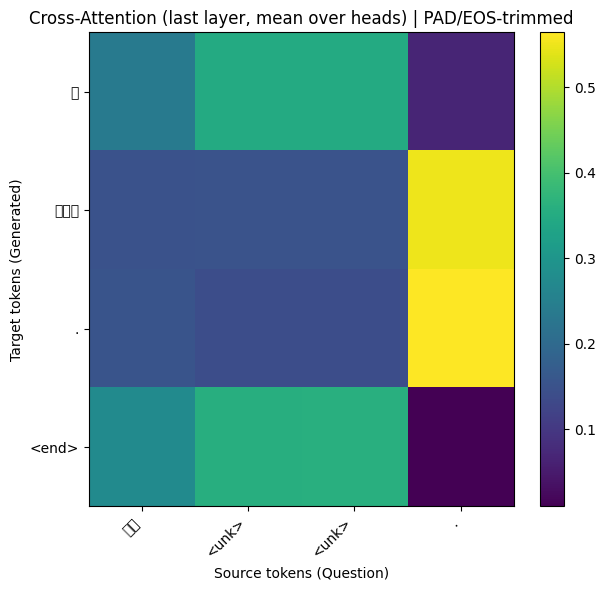

In [48]:
plot_cross_attention("집에 있는다는 소리야.")